In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use("ggplot")

In [2]:
df = pd.read_csv(r"C:\Users\prave\OneDrive\Documents\AI-Retail-Sales-Analytics\data\raw\Sample - Superstore.csv", encoding="latin1")

df["Order Date"] = pd.to_datetime(df["Order Date"])
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
ml_df = df.groupby("Customer Name").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Quantity": "sum"
}).reset_index()

ml_df.head()

,Customer Name,Sales,Profit,Quantity
0,Aaron Bergman,886.156,129.3465,13
1,Aaron Hawkins,1744.700,365.2152,54
2,Aaron Smayling,3050.692,-253.5746,48
3,Adam Bellavance,7755.620,2054.5885,56
4,Adam Hart,3250.337,281.1890,75


In [4]:
X = ml_df[["Sales", "Profit", "Quantity"]]

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)
ml_df["Cluster"] = kmeans.fit_predict(X)

ml_df.head()

,Customer Name,Sales,Profit,Quantity,Cluster
0,Aaron Bergman,886.156,129.3465,13,0
1,Aaron Hawkins,1744.700,365.2152,54,0
2,Aaron Smayling,3050.692,-253.5746,48,0
3,Adam Bellavance,7755.620,2054.5885,56,1
4,Adam Hart,3250.337,281.1890,75,0


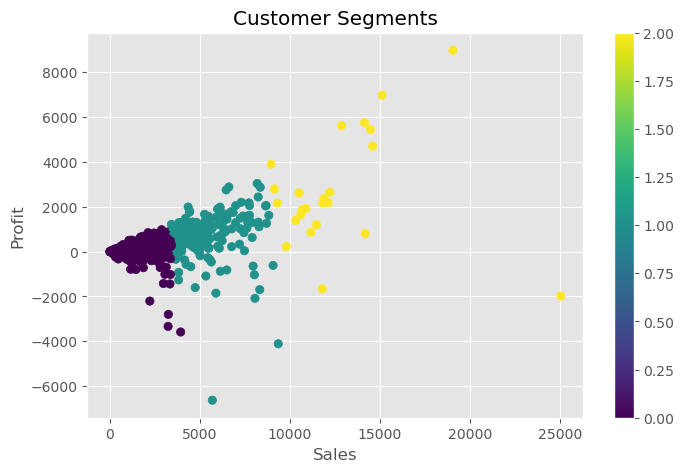

In [6]:
plt.figure(figsize=(8,5))

plt.scatter(ml_df["Sales"], ml_df["Profit"], c=ml_df["Cluster"], cmap="viridis")

plt.title("Customer Segments")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.colorbar()
plt.show()

In [7]:
X = df[["Quantity", "Discount", "Profit"]]
y = df["Sales"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
y_pred = model.predict(X_test)

In [11]:
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: -0.1518172010606389
RMSE: 824.8499599151103


In [12]:
plt.savefig("images/sales_trend.png")

FileNotFoundError: [Errno 2] No such file or directory: 'images/sales_trend.png'

<Figure size 640x480 with 0 Axes>

In [13]:
import os
import matplotlib.pyplot as plt

# Create the images directory if it doesn't exist
os.makedirs("images", exist_ok=True)

# Now save the figure - this will work because the directory exists
plt.savefig("images/sales_trend.png")

<Figure size 640x480 with 0 Axes>

In [1]:
import os
os.getcwd()

'C:\\Users\\prave\\anaconda_projects\\a8481d99-7649-416e-82d6-a1655f339bb8'